<a href="https://colab.research.google.com/github/eesabatan/coursework-2/blob/main/The_final_CRM_coursework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# numpy and pandas used for data manipulation
import numpy as np
import pandas as pd
# matplotlib used to visually represent data
import matplotlib.pyplot as plt
# yfinance used to import historical data
import yfinance as yfin

In [ ]:
#set ticker
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)

#Import data
data = ticker.history(period='5y')

In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-12-16 00:00:00-05:00,158.800507,162.350006,158.184006,162.048004,88552000,0.0,0.0
2020-12-17 00:00:00-05:00,162.500000,163.175507,161.050003,161.804001,69486000,0.0,0.0
2020-12-18 00:00:00-05:00,162.199493,162.470993,158.580002,160.082504,119914000,0.0,0.0
2020-12-21 00:00:00-05:00,160.000504,161.348495,158.300003,160.309006,76736000,0.0,0.0
2020-12-22 00:00:00-05:00,160.141998,161.100006,159.003998,160.326004,47388000,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-09 00:00:00-05:00,226.839996,228.570007,225.110001,227.919998,25841700,0.0,0.0
2025-12-10 00:00:00-05:00,228.809998,232.419998,228.460007,231.779999,38790700,0.0,0.0
2025-12-11 00:00:00-05:00,230.710007,232.110001,228.690002,230.279999,28249600,0.0,0.0


<Axes: xlabel='Date', ylabel='Amazon'>

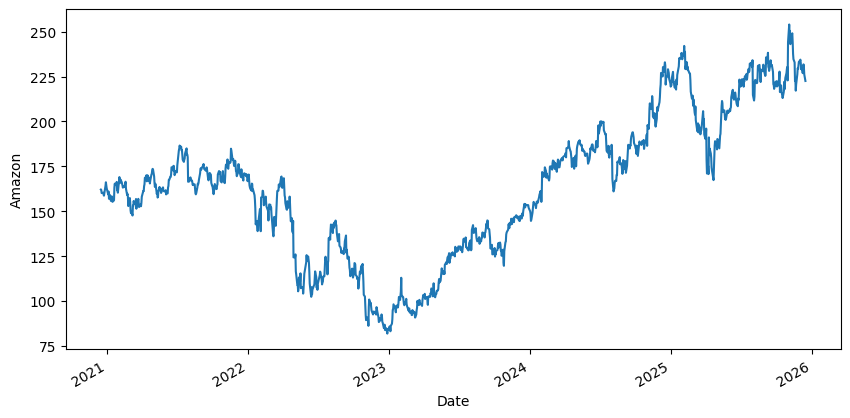

In [ ]:
plt.ylabel("Amazon")

data['Close'].plot(figsize=(10,5))


In [ ]:
# simple moving average (SMA)
data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()
data['SMA_50'] = data['Close'].shift(1).rolling(window=50).mean()

# exponential moving averages (EMA)
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

#calculate realtive strength index (RSI)
delta = data['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2020-12-16 00:00:00-05:00,158.800507,162.350006,158.184006,162.048004,88552000,0.0,0.0,NaN,NaN,162.048004,NaN
2020-12-17 00:00:00-05:00,162.500000,163.175507,161.050003,161.804001,69486000,0.0,0.0,NaN,NaN,162.024766,NaN
2020-12-18 00:00:00-05:00,162.199493,162.470993,158.580002,160.082504,119914000,0.0,0.0,NaN,NaN,161.839788,NaN
2020-12-21 00:00:00-05:00,160.000504,161.348495,158.300003,160.309006,76736000,0.0,0.0,NaN,NaN,161.694000,NaN
2020-12-22 00:00:00-05:00,160.141998,161.100006,159.003998,160.326004,47388000,0.0,0.0,NaN,NaN,161.563714,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-09 00:00:00-05:00,226.839996,228.570007,225.110001,227.919998,25841700,0.0,0.0,231.722501,228.532401,230.467836,58.041326
2025-12-10 00:00:00-05:00,228.809998,232.419998,228.460007,231.779999,38790700,0.0,0.0,230.698501,228.647401,230.592803,62.247373
2025-12-11 00:00:00-05:00,230.710007,232.110001,228.690002,230.279999,28249600,0.0,0.0,229.832500,228.891600,230.563013,69.872968


In [ ]:
data = data.dropna()
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-03-02 00:00:00-05:00,157.173492,158.175995,154.356003,154.726501,51916000,0.0,0.0,162.899100,161.558651,160.165631,31.396405
2021-03-03 00:00:00-05:00,154.059006,155.389008,149.750000,150.250000,79774000,0.0,0.0,162.278226,161.412220,159.221285,27.890335
2021-03-04 00:00:00-05:00,150.600006,152.906494,147.271500,148.878494,109632000,0.0,0.0,161.340726,161.181140,158.236258,27.760406
2021-03-05 00:00:00-05:00,150.250000,150.449997,144.050003,150.022995,107772000,0.0,0.0,160.503326,160.957060,157.454042,28.576522
2021-03-08 00:00:00-05:00,150.750000,153.229507,147.565506,147.597504,83700000,0.0,0.0,159.676975,160.751340,156.515324,26.922655
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-09 00:00:00-05:00,226.839996,228.570007,225.110001,227.919998,25841700,0.0,0.0,231.722501,228.532401,230.467836,58.041326
2025-12-10 00:00:00-05:00,228.809998,232.419998,228.460007,231.779999,38790700,0.0,0.0,230.698501,228.647401,230.592803,62.247373
2025-12-11 00:00:00-05:00,230.710007,232.110001,228.690002,230.279999,28249600,0.0,0.0,229.832500,228.891600,230.563013,69.872968


In [ ]:
# Initialising x and assigning the two feture variables
x = data[['SMA_20', 'SMA_50']]

# getting the head of the data
x.head()

,SMA_20,SMA_50
Date,,
2021-03-02 00:00:00-05:00,162.899100,161.558651
2021-03-03 00:00:00-05:00,162.278226,161.412220
2021-03-04 00:00:00-05:00,161.340726,161.181140
2021-03-05 00:00:00-05:00,160.503326,160.957060
2021-03-08 00:00:00-05:00,159.676975,160.751340


In [ ]:
# Setting the dependent variable
y = data['Close']

# getting the head of the data
y.head()

,Close
Date,
2021-03-02 00:00:00-05:00,154.726501
2021-03-03 00:00:00-05:00,150.250000
2021-03-04 00:00:00-05:00,148.878494
2021-03-05 00:00:00-05:00,150.022995
2021-03-08 00:00:00-05:00,147.597504


In [ ]:
# setting the training set to 80% of the data
training = 0.7
t = int(training*len(data))

# training dataset
x_train = x[:t]
y_train = y[:t]

# testing dataset
x_test = x[t:]
y_test = y[t:]

In [ ]:
# Train model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(rmse, r2)


9.764169316616716 0.7788202986030047


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(x_train,y_train)

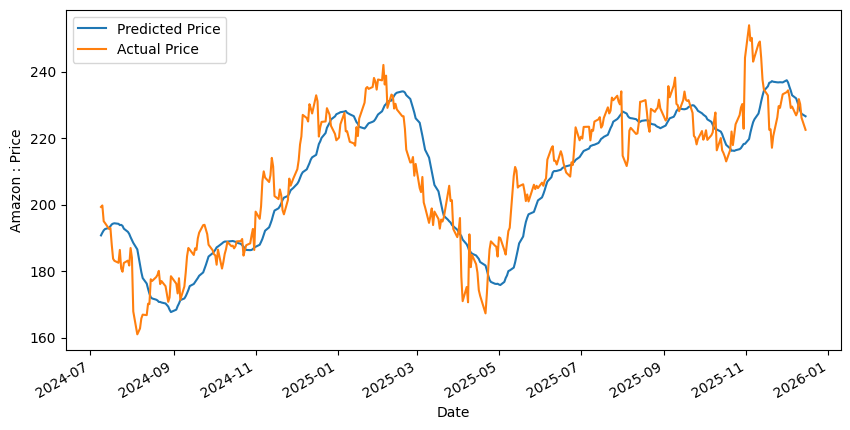

In [ ]:
predicted_price = model.predict(x_test)
predicted_price = pd.DataFrame(predicted_price, index=y_test.index, columns=['Close'])
predicted_price.plot(figsize=(10,5))
y_test.plot()
plt.legend(['Predicted Price', 'Actual Price'])
plt.ylabel("Amazon : Price")
plt.show()

In [ ]:
# Computing the accuracy of our model
R_squared_score =model.score(x[t:],y[t:])*100
accuracy = ("{0:.2f}".format(R_squared_score))
print ("The model has a " + accuracy + "% accuracy.")

The model has a 77.88% accuracy.


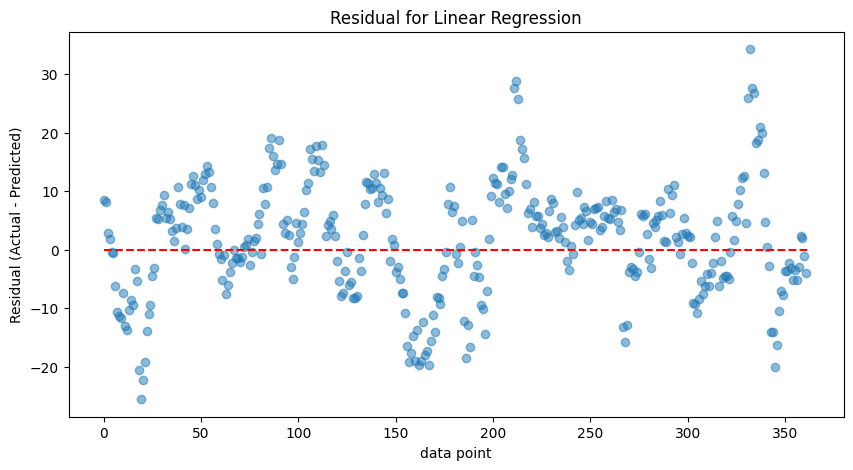

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

# Create residuals plot
plt.figure(figsize=(10,5))
plt.scatter(range(len(residuals)), residuals, alpha=0.5)
plt.hlines(y=0, xmin=0, xmax=len(residuals), colors='r', linestyles='dashed')
plt.title('Residual for Linear Regression')
plt.xlabel('data point')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()


In [ ]:
print(f'alpha = {model.intercept_}')
print(f'betas = {model.coef_}')

alpha = 3.7058895337276
betas = [ 1.27838488 -0.30236337]


In [ ]:
#formulate linear regression model
#predicted_price= 3.83+1.27*'SMA_20' - 0.30*'SMA_50'

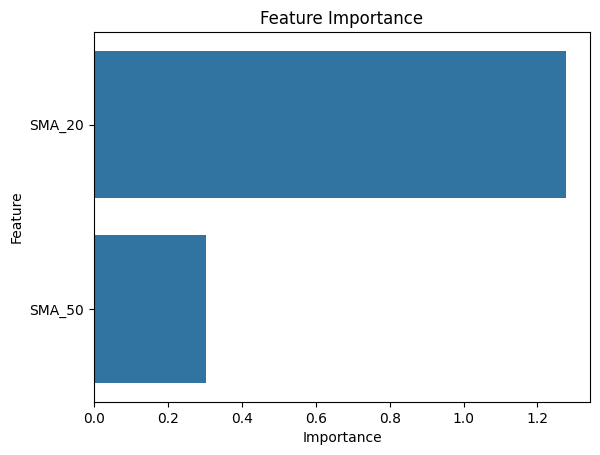

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Features and coefficients
features = x.columns
coefficients = model.coef_

importance = np.abs(coefficients)

# Create a horizontal bar plot
sns.barplot(x=importance, y=features)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Features for Random Forest
X_rfr = data[['SMA_20', 'EMA_20', 'SMA_50', 'RSI']]
y_rfr = data['Close']

# Split train and test datasets
training = 0.7
t = int(training * len(data))

X_train_rfr = X_rfr[:t]
y_train_rfr = y_rfr[:t]

X_test_rfr = X_rfr[t:]
y_test_rfr = y_rfr[t:]

# Define and train Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train_rfr, y_train_rfr)

# Predict using test dataset
y_pred_rfr = rfr.predict(X_test_rfr)

# calculate performance
rmse_rfr = np.sqrt(mean_squared_error(y_test_rfr, y_pred_rfr))
r2_rfr = r2_score(y_test_rfr, y_pred_rfr)

print("Random Forest Regressor RMSE:", rmse_rfr)
print("Random Forest Regressor R²:", r2_rfr)

Random Forest Regressor RMSE: 23.40245742884697
Random Forest Regressor R²: -0.2705670595458807


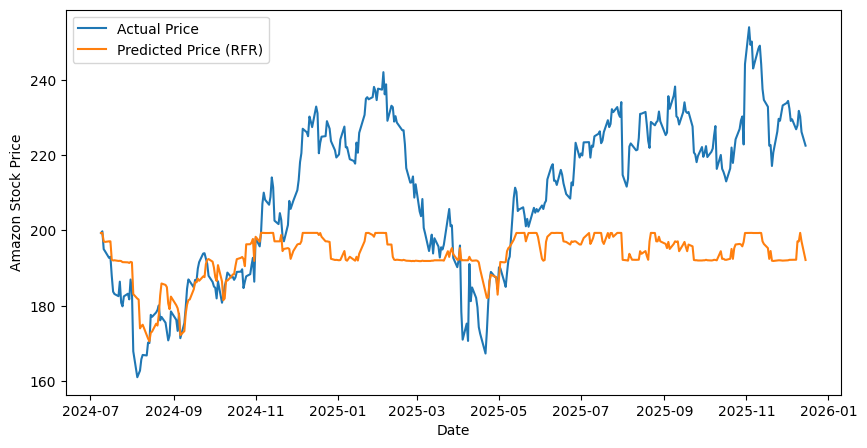

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_rfr.index, y_test_rfr.values, label='Actual Price')
plt.plot(y_test_rfr.index, y_pred_rfr, label='Predicted Price (RFR)')
plt.xlabel('Date')
plt.ylabel('Amazon Stock Price')
plt.legend()
plt.show()


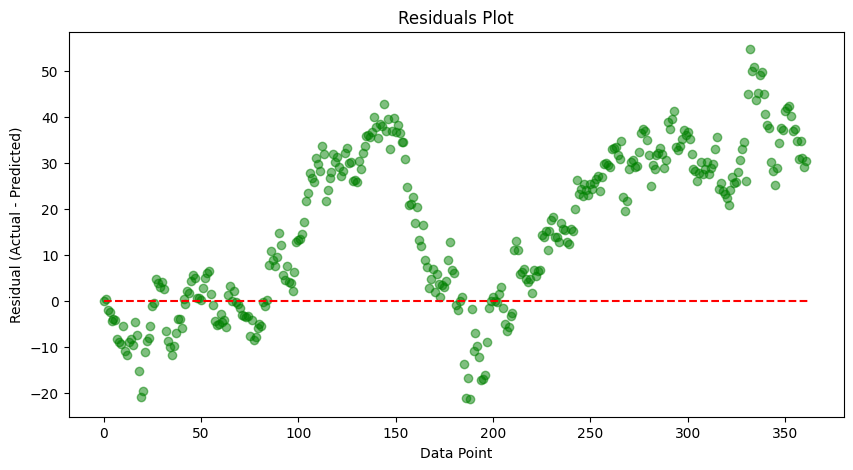

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals_rfr = y_test_rfr - y_pred_rfr

# Create residuals plot
plt.figure(figsize=(10,5))
plt.scatter(range(len(residuals_rfr)), residuals_rfr, alpha=0.5, color='green')
plt.hlines(y=0, xmin=0, xmax=len(residuals_rfr), colors='r', linestyles='dashed')
plt.title('Residuals Plot')
plt.xlabel('Data Point')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()


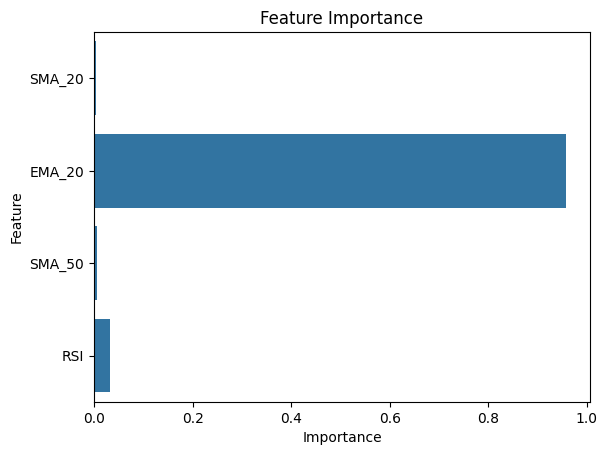

In [ ]:
import seaborn as sns

importances = rfr.feature_importances_
features = X_rfr.columns

sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


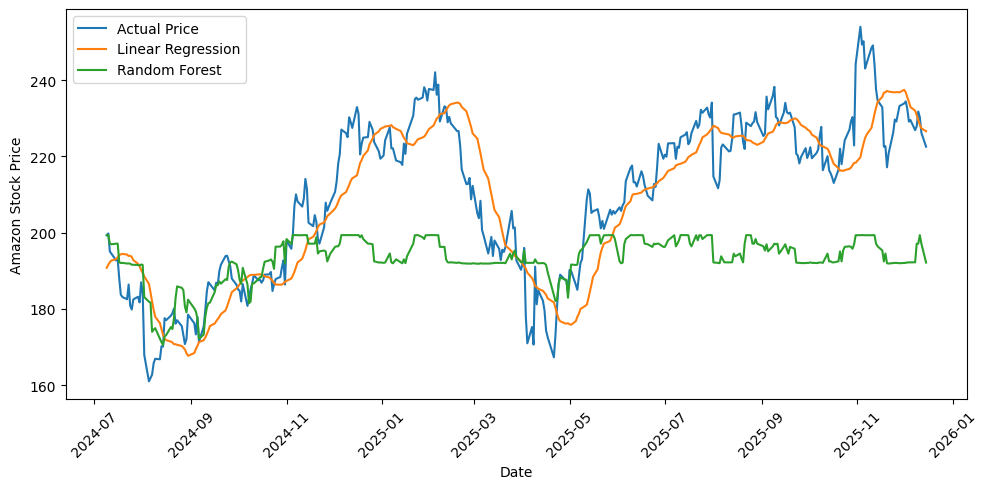

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test.values, label='Actual Price')
plt.plot(y_test.index, y_pred, label='Linear Regression')
plt.plot(y_test.index, y_pred_rfr, label='Random Forest')

plt.xlabel('Date')
plt.ylabel('Amazon Stock Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
print(f"Linear Regression RMSE: {rmse:.2f}, R²: {r2:.2f}")
print(f"Random Forest RMSE: {rmse_rfr:.2f}, R²: {r2_rfr:.2f}")


Linear Regression RMSE: 9.76, R²: 0.78
Random Forest RMSE: 23.40, R²: -0.27
